# Проект. Исследование стартапов

## Введение

### Цели и задачи проекта
**Цель:**
Изучить рынок стартапов, исследовать динамику и структуру финансирования стартапов и оценить перспективы выходы на изучаемый рынок 

**Задачи:**
- загрузить и осуществить первичную обработку данных;
- предобработать данные: преобразовать типы и форматы данных, заполнить пропуски, обработать дубликаты;
- провести исследовательский анализ; 
- сформировать выводы и оценить перпективы выхода на рынок стартапов. 


## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

### Вывод общей информации


In [1]:
# установка библиотек, необходимых для анализа
import pandas as pd

# установка библиотек, необходимых для визуазации
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# выполним закгрузки данных
df_invest = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [3]:
df_return = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv") 

In [4]:
#выведем общкю информацию о данных 
display(df_invest.head())

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df_invest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [6]:
 display(df_return.head())

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [7]:
df_return.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


**Промежуточный вывод:**

Для анализа предоставлено два датасета `df_invest` и `df_return`, первый содержить информацию о различных типах инвестирования, второй - информацию о возвратах по соответствующим типам инвестирования. 

Датасет `df_invest` содержитт 54 294 строки и 40 столбцов. Стоит отметить, что в каждом столбце присутствуют пропуски, основываясь на структуре датасета можем предположить: столбец `name` должен содержать уникальные значения - важно учесть при дальнейшей обработке данных. 

В 19-39 столбцах содержиться информация о разных типах финансирования, использование формата `float64` логично в этом случае; стобцы 12-18 содержит информацию в виде дат, в это случае необходимо изменить стороковый и числовой тип данных на `datetime64`; столбец `funding_total_usd ` содержит информацию об общем объеме привлеченных инвестиций, поэтому также требует числового формата, а не строкового; все остальные столбцы не требуют изменения типа данных, так как содержащаяся в них информация свойственна использованному типу.

Датасет `df_return` содержиит 15 строк и 14 столбцов, в данном датасете отсутсвуют пропуски в данных, а типы данных столбцов полностью отражают их суть.

Названия столбцов в обоих датасетах корректны и отражают суть указанных данных.

### 1.2. Предобработка данных

In [8]:
# проверим формат названий столбцов в датафрейме df_invest
df_invest.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [9]:
# уберем лишние пробелы по бокам
df_invest.columns = df_invest.columns.str.strip()
df_invest.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [10]:
# проверим формат названий столбцов в датафрейме df_return
df_return.columns

Index(['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
       'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding'],
      dtype='object')

Названия столбцов датафрейма df_invest были приведены к единому формату: осуществили удаление лишних пробелов; названия столбцов второго датафрейма не потребовали обработки.

В ходе анализа активно будет использоваться столбец `funding_total_usd`, выполним его предобработку: уберем выделение разрядов и приведем его к числовому типу, для удобства вычислений приведем значение столбца к млн.

In [11]:
df_invest['funding_total_usd'] = df_invest['funding_total_usd'].astype(str).str.replace(',', '', regex=False)
df_invest['funding_total_usd'] = df_invest['funding_total_usd'].str.strip().replace(['nan', 'NaN', 'NA', 'null', '', ' -'], pd.NA)
df_invest['funding_total_usd'] = pd.to_numeric(df_invest['funding_total_usd'],errors='coerce')
df_invest['funding_total_usd'] = df_invest['funding_total_usd'] / 1000000

In [12]:
df_invest['funding_total_usd'].isna().sum()

13387

Выполним обработку типов данных в столбцах, которые хранят значения даты и времени.

In [13]:
for col in (['founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at']):
    df_invest[col] = pd.to_datetime(df_invest[col],errors='coerce')

В датасете `cb_returns` сделаем столбец `year` индексом всего датасета.

In [14]:
df_return = df_return.set_index('year')

In [15]:
# рассчитаем процент пропусков в тестовых столбцах датасета df_invest
df_invest[['name','homepage_url','market','status','country_code','state_code','region','city']].isna().sum() / df_invest.shape[0] *100

name             8.945740
homepage_url    15.296350
market          16.239363
status          11.364055
country_code    18.655837
state_code      44.448742
region          18.655837
city            20.208494
dtype: float64

In [16]:
# заполним пропуски в текстовых столбцах `no_data`
df_invest[['name','homepage_url','market','status','country_code','state_code','region','city']].fillna('no_data')

,name,homepage_url,market,status,country_code,state_code,region,city
0,Harvard University,http://harvard.edu,Education,operating,USA,MA,Boston,Cambridge
1,University of New Brunswick,http://www.unb.ca,no_data,operating,no_data,no_data,no_data,no_data
2,DuPont,http://www.dupont.com,Business Services,operating,USA,DE,"Wilmington, Delaware",Wilmington
3,University of Michigan,http://www.umich.edu/,Education,operating,USA,MI,Detroit,Ann Arbor
4,Case Western Reserve University,http://www.case.edu,Education,operating,USA,OH,Cleveland,Cleveland
...,...,...,...,...,...,...,...,...
54289,no_data,no_data,no_data,no_data,no_data,no_data,no_data,no_data
54290,no_data,no_data,no_data,no_data,no_data,no_data,no_data,no_data
54291,no_data,no_data,no_data,no_data,no_data,no_data,no_data,no_data
54292,no_data,no_data,no_data,no_data,no_data,no_data,no_data,no_data


Дальнейших анализ подразумевает подразделение данных по секторам, для корректной обрабоки данных проверим уникальность сегментов, а также их тип данных. Проведем нормализацию по столбцу `market`

In [17]:
df_invest['market'] = df_invest['market'].str.strip()
df_invest['market'] = df_invest['market'].str.lower()
df_invest['market'].unique()

array(['education', nan, 'business services', 'social media',
       'hardware + software', 'biotechnology', 'utilities', 'hospitality',
       'enterprise software', 'manufacturing', 'pharmaceuticals',
       'finance', 'shipping', 'design', 'nonprofits', 'software',
       'curated web', 'health care', 'health and wellness', 'media',
       'politics', 'clean technology', 'financial services',
       'consumer electronics', 'web hosting', 'e-commerce', 'automotive',
       'local businesses', 'medical', 'fashion', 'advanced materials',
       'banking', 'security', 'publishing', 'networking', 'analytics',
       'semiconductors', 'public relations', 'energy', 'cosmetics',
       'jewelry', 'nanotechnology', 'travel', 'retail',
       'public transportation', 'consulting', 'construction',
       'real estate', 'environmental innovation', 'restaurants',
       'services', 'technology', 'telecommunications', 'insurance',
       'information technology', 'legal',
       'health care info

Обработка дубликатов, исключение безинформативных данных.

In [18]:
# найдем количество полных дубликатов
data_del_1 = df_invest.duplicated().sum()
data_del_1

4855

In [19]:
df_invest = df_invest.drop_duplicates()

In [20]:
#найдем количество безинформативных данных 
data_del_2 = df_invest['funding_total_usd'].isna().sum()
df_invest = df_invest.dropna(subset=['funding_total_usd'])
data_del_2

8532

In [21]:
# проверим размерность датасета после очистки 
df_invest.shape

(40907, 40)

In [22]:
#проверим наличие полных дубликатов в датасете df_return
df_return.duplicated()

year
2000    False
2001    False
2002    False
2003    False
2004    False
2005    False
2006    False
2007    False
2008    False
2009    False
2010    False
2011    False
2012    False
2013    False
2014    False
dtype: bool

Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмем приблизительно середину интервала между этими двумя датами.

In [23]:
# оценим начальный формат столбцов
df_invest[['first_funding_at','mid_funding_at','last_funding_at']].head(20)

,first_funding_at,mid_funding_at,last_funding_at
0,2014-01-06,NaT,2014-01-06
1,2014-05-15,NaT,2014-05-15
2,2009-07-02,2009-07-02,2009-07-02
3,2013-11-21,2013-11-21,2014-11-03
4,2014-01-14,NaT,2014-01-14
5,2014-10-23,NaT,2014-10-23
6,2013-09-05,2013-09-05,2013-12-22
7,2014-01-12,NaT,2014-01-12
8,2014-09-30,NaT,2014-09-30
9,2007-10-01,2007-10-01,2008-03-01


In [24]:
def miidle_date(row):
    first = row['first_funding_at']
    last = row['last_funding_at']
    if pd.isna(first) or pd.isna(last):
        return pd.NaT
    count_day = (last - first) 
    mid = first + count_day/2
    return mid
df_invest['mid_funding_at'] = df_invest.apply(miidle_date,axis=1)
df_invest[['first_funding_at','mid_funding_at','last_funding_at']].head(20)

,first_funding_at,mid_funding_at,last_funding_at
0,2014-01-06,2014-01-06 00:00:00,2014-01-06
1,2014-05-15,2014-05-15 00:00:00,2014-05-15
2,2009-07-02,2009-07-02 00:00:00,2009-07-02
3,2013-11-21,2014-05-13 12:00:00,2014-11-03
4,2014-01-14,2014-01-14 00:00:00,2014-01-14
5,2014-10-23,2014-10-23 00:00:00,2014-10-23
6,2013-09-05,2013-10-29 00:00:00,2013-12-22
7,2014-01-12,2014-01-12 00:00:00,2014-01-12
8,2014-09-30,2014-09-30 00:00:00,2014-09-30
9,2007-10-01,2007-12-16 00:00:00,2008-03-01


Оценка полноты данных: какой процент был отброшен?

In [25]:
del_data = data_del_1 + data_del_2
del_data / 54294 *100

24.656499797399345

In [26]:
df_invest.shape

(40907, 40)

In [27]:
df_return.shape

(15, 13)

**Промежуточный вывод:**
В ходе предобработки данных был отброшено 24,7% от изначальных данных датасета `df_invest`, среди который полные дубликаты и пропуски в столбцах, необходимых для анализа. По результатам предобработки датасет имеет следующую размерность: 40 907 строк и 40 столбцов, что позволяет провести исследование. Датасет `df_return` не содержал данные, которые способны исказить анализ, поэтому сохранил свою размерность: 15 строк и 14 столбцов.

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Выполним разделение всех компаний на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Построим два графика, визуализирующих соотношение получившихся групп по количеству компаний и объему инвестиций.
Для ясности и согласованности будем использовать единую цветовую палитру для всех графиков, чтобы каждая категория (например, «Единичное финансирование») всегда отображалась одним цветом.

In [28]:
# выполним сегментирование рынка по раундам финансирования
def group(row):
    f = row['first_funding_at']
    l = row['last_funding_at']
    diff = (l-f).days / 365.25
    if diff==0: return 'единичное'
    elif diff<=1: return 'год и менее'
    elif diff>1: return  'более года'
    return 'нет данных'

df_invest['group_invest'] = df_invest.apply(group,axis=1)
df_invest['group_invest']

0          единичное
1          единичное
2          единичное
3        год и менее
4          единичное
            ...     
49433      единичное
49434      единичное
49435      единичное
49436      единичное
49437      единичное
Name: group_invest, Length: 40907, dtype: object

In [29]:
#рассчитаем соотношение сегментов в каждой группе 
groups = df_invest.groupby('group_invest')['name'].count()
groups

group_invest
более года     12291
год и менее     4325
единичное      24288
нет данных         2
Name: name, dtype: int64

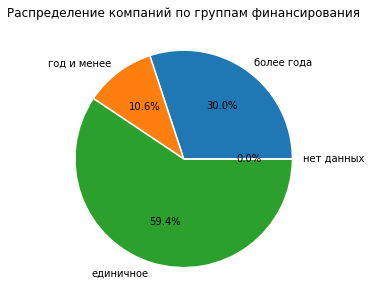

In [30]:
# визуализируем распределение компаний по группам финансирования
plt.figure(figsize = (8,5))
plt.pie(groups,labels = ['более года','год и менее','единичное','нет данных'],autopct='%1.1f%%',wedgeprops={'linewidth':1.5,'edgecolor':'white'})
plt.title('Распределение компаний по группам финансирования')
plt.show()

In [31]:
# рассчитаем распределение объема инвестиций по группам 
finance = df_invest.groupby('group_invest')['funding_total_usd'].sum()
finance

group_invest
более года     402708.997604
год и менее     46868.002307
единичное      201322.403233
нет данных         34.300000
Name: funding_total_usd, dtype: float64

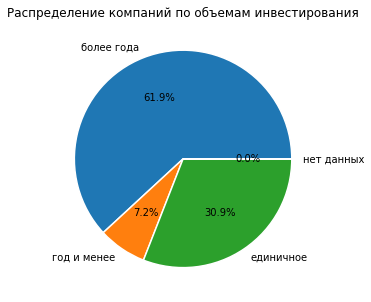

In [32]:
#
plt.figure(figsize = (8,5),)
plt.pie(finance,labels = ['более года','год и менее','единичное','нет данных'],autopct='%1.1f%%',wedgeprops={'linewidth':1.5,'edgecolor':'white'})
plt.title('Распределение компаний по объемам инвестирования')
plt.show()

**Промежуточный вывод:**

В ходе изучения распределения компаний по группам выяснилось, что наибольшее количество компаний относятся к группе "единичное финансирование", их количество составляет 24 288, что составляет 59,4% от всего рынка, но что касается объемов инвестирования данный сектор не находится в топе, объем привлекаемых инвестиции этой группой составляет 30,9% на рынке, в то время как группа "более года" (между раундами финансирования прошло более года), где количество компаний значительно меньше - 12 291 (30%), привлекла 61,9% инвестиций. Сегмент "год и менее" оказался самым не результативным, он затронул 4325 компаний и принес 7,2% инвестиций. 

Таким образом, можем сделать вывод, что долгосроные инвестиции значительно выгоднее единоразовых, однако немногие компании готовы идти на них, возможно это связано со сферой организации и ее размерах, оборотом. Дальнейшее иследование требует детального изучения соответсвующих данных. 

### 2.2 Выделение средних и нишевых сегментов рынка

Изучим распределение компаний по сегментам рынка - столбец `market`, используя следующую сегментацию 
- сегменты, к которым относится более 120 компаний, отнесите к массовым;
- сегменты, в которые входит от 35 до 120 включительно, отнесите к средним;
- сегменты до 35 компаний отнесите к нишевым. 

Рассчитам, сколько сегментов попадает в каждую из категорий и визуализируем полученные данные.

In [33]:
#рассчитаем распределение компаний по сегментам
df_section = df_invest.groupby('market').agg({'name':'count'})
df_section = df_section.reset_index()
df_section.sort_values(by = 'name',ascending=False)

,market,name
337,software,4812
30,biotechnology,3590
232,mobile,2344
109,e-commerce,1866
87,curated web,1693
...,...,...
144,fleet management,1
292,professional services,1
293,project management,1
143,flash storage,1


In [34]:
# классифицируем по количеству компаний в сегменте
def section(row):
    count = row['name']
    if count>120: return 'массовые'
    elif count>35 and count<=120: return 'средние'
    else: return 'нишевые'
df_section['section'] = df_section.apply(section,axis=1)
df_section

,market,name,section
0,3d,2,нишевые
1,3d printing,3,нишевые
2,ad targeting,1,нишевые
3,advertising,1107,массовые
4,advertising networks,1,нишевые
...,...,...,...
389,weddings,2,нишевые
390,wholesale,2,нишевые
391,wine and spirits,2,нишевые
392,wireless,64,средние


In [35]:
#рассчитаем количество компаний в каждом сегменты
df_section.groupby('section')['market'].count()

section
массовые     48
нишевые     289
средние      57
Name: market, dtype: int64

На основе исследования получили, что наибольшаа часть сегментов сосредоточена в категориях средних и нишевых, поэтому далее изучим детальное рапсределение количества компаний по сегментам внутри каждой категории (нишевые и средние). 
Стоит учесть, что в "нишевых" набольшее количество компаний, распределение которых также стоит изучить.

In [36]:
# рассчитыем сколько сегментов приходит на определенное количество компаний
df_section['name'].value_counts()

1       128
2        69
3        26
4        14
5        12
       ... 
79        1
77        1
74        1
71        1
1003      1
Name: name, Length: 99, dtype: int64

Заметим, что большая количество компании по сегментам нишевой категории сосредоточена в диапозоне от 1 до 5, поэтому для большей наглядности распределения компаний по сегментам отфильтруем данные и рассмотрим количество компаний в сегменте от 6 и выше.

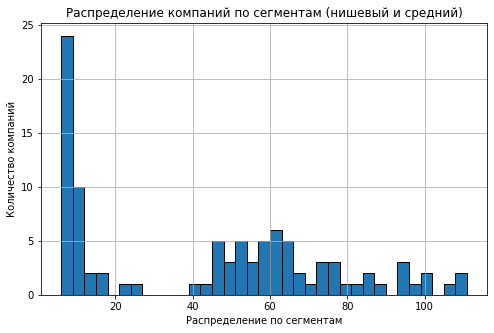

In [37]:
df_section['name'][(df_section['name']<120)&(df_section['name']>5)].plot(
    kind='hist',
    bins=35,
    grid=True,
    edgecolor='black',figsize = (8,5))
plt.title('Распределение компаний по сегментам (нишевый и средний)')
plt.xlabel('Распределение по сегментам')
plt.ylabel('Количество компаний')
plt.show()

**Промежуточный вывод:**

Среди нишевых большее количество составляют сегменты, в которых до 10 компаний, среди средних - количество компаний в сегменте корьируетс от 40 до 120, но в среднем количество компаний ледит в промежутке от 45-65. Далее будем рассматривать массовые сегменты отдельно, а сегменты нишевые и средние поместим в две отдельные категории: niche для нишевых и mid для средних.

In [38]:
#выполним присоединение столбца с категорией сегмента в датасет df_invest
df_invest = df_invest.merge(df_section[['market','section']],on = 'market',how='left')

In [39]:
df_invest.drop_duplicates()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,group_invest,section
0,Harvard University,http://harvard.edu,|Education|,education,90.0000,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,массовые
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,2.0000,operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,NaN
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,business services,9.0000,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,средние
3,University of Michigan,http://www.umich.edu/,|Education|,education,7.7000,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,год и менее,массовые
4,Case Western Reserve University,http://www.case.edu,|Education|,education,0.5400,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,массовые
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40902,RiverSilica,http://riversilica.com,NaN,NaN,1.5000,operating,IND,NaN,Bangalore,Bangalore,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,NaN
40903,SouthGobi Resources,http://southgobi.com,|Mining Technologies|,mining technologies,9.0000,operating,CAN,BC,Vancouver,Vancouver,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,нишевые
40904,DigiByte,http://digibyte.co,NaN,NaN,0.2500,operating,USA,CA,Los Angeles,Santa Monica,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,NaN
40905,Xeltis,http://xeltis.com,NaN,NaN,34.0000,operating,CHE,NaN,Zurich,Zürich,...,0.0,34000000.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,NaN


In [40]:
# заполним сегменты заглушками 
df_invest.loc[df_invest['section'] == 'средние', 'market'] = 'mid'
df_invest.loc[df_invest['section'] == 'нишевые', 'market'] = 'niche'
df_invest[df_invest['section']=='нишевые'].head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H,group_invest,section
37,CESC,https://www.cesc.co.in/,|Utilities|,niche,80.0,operating,IND,NaN,Kolkata,Kolkata,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,нишевые
57,The Exchange,http://www.shopmyexchange.com/,|Politics|,niche,940.0,operating,USA,TX,Dallas,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,более года,нишевые
99,Pulaski Bank,https://www.pulaskibank.com/our-story/,|Banking|,niche,6.7,operating,USA,MO,MO - Other,Louisiana,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,нишевые
102,United Way of Central Alabama,http://uwca.org,|Politics|,niche,37.9,operating,USA,AL,Birmingham,Birmingham,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,нишевые
127,Senco Gold,http://www.sencogold.co.in/,|Jewelry|,niche,13.0,operating,IND,NaN,IND - Other,Calcutta,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,нишевые


## Шаг 3. Работа с выбросами и анализ
### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

In [41]:
# определим типичный диапозон финансирования для разных сегментов (используем IQR)
list_clean = df_invest[df_invest['market'].notna()].copy() #убираем пропуски
IQR_dict = {}

for seg in list_clean['market'].unique():
    group =  list_clean[list_clean['market']==seg]['funding_total_usd']
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + IQR*1.5
    IQR_dict[seg] = {'Q1':Q1,'Q3':Q3,'IQR':IQR,'upper':upper}
IQR_dict_df = pd.DataFrame(IQR_dict).T
IQR_dict_df.sort_values(by='IQR')

,Q1,Q3,IQR,upper
marketplaces,0.080943,2.032737,1.951794,4.960428
apps,0.100000,2.169575,2.069575,5.273937
startups,0.100000,2.200000,2.100000,5.350000
sports,0.100000,2.962500,2.862500,7.256250
social media,0.125000,3.000000,2.875000,7.312500
social network media,0.112500,3.000000,2.887500,7.331250
saas,0.250000,4.073750,3.823750,9.809375
photography,0.178750,4.248096,4.069346,10.352116
nonprofits,0.213232,4.590000,4.376768,11.155152
music,0.200000,4.601811,4.401810,11.204526


In [42]:
# определим какие компании имеют аномальные инвестиции
list_clean['anomaly']=False
for index,row in list_clean.iterrows():
    total_finance = row['funding_total_usd']
    market = row['market']
    up = IQR_dict[market]['upper']
    if total_finance > up: 
        list_clean.loc[index,'anomaly'] = True
list_clean.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_B,round_C,round_D,round_E,round_F,round_G,round_H,group_invest,section,anomaly
0,Harvard University,http://harvard.edu,|Education|,education,90.00,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,массовые,True
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,mid,9.00,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,средние,False
3,University of Michigan,http://www.umich.edu/,|Education|,education,7.70,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,год и менее,массовые,False
4,Case Western Reserve University,http://www.case.edu,|Education|,education,0.54,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,массовые,False
6,Tulane University,http://tulane.edu/,|Education|,education,12.00,operating,USA,LA,New Orleans,New Orleans,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,год и менее,массовые,True


In [43]:
# посчитаем доли (внутри каждого сегмента)
filt_df = list_clean.groupby('market')['anomaly'].sum() / list_clean.groupby('market')['anomaly'].count()
filt_df.sort_values(ascending=False).head(15)

market
real estate        0.172043
entertainment      0.166667
consulting         0.166189
search             0.164948
cloud computing    0.164474
saas               0.161765
photography        0.161765
technology         0.159664
video              0.159574
niche              0.159036
travel             0.154545
networking         0.153846
internet           0.153527
big data           0.153333
marketplaces       0.153061
Name: anomaly, dtype: float64

**Промежуточные выводы:**

С помощью метода IQR были рассчитаны типичные диапозоныы финансирования для каждого сегмента. Наибольший диапозон заметен у `semiconductors` - 28295282 долл, `clean techology` - 26696619,5  долл, `health care` - 26450000 долл; наименьшие: `marketplaces` - 1951794 долл, `apps` - 2069575  долл, `startups` - 2100000 долл.

Далее были найдены компании, имеющие аномальное финансирования, такие компании отмечены в столбце `anomaly` как `True`. На основе чего были рассчитаны доли таких компаний внутри каждого сегмента. Среди лидеров в данном случае являются слеюущие сегменты:
- `real estate` 17,2%
- `entertainment` 16,7%
- `consulting` 16,2%

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

In [44]:
# проверим, присутствует ли данные в датасете за весь 2014 год
df_filt_dt = df_invest['mid_funding_at'].dt.to_period('M')
df_filt_dt = df_filt_dt[df_filt_dt.dt.year>=2014]
pd.Series(df_filt_dt.unique()).sort_values()

0     2014-01
5     2014-02
8     2014-03
10    2014-04
1     2014-05
6     2014-06
4     2014-07
7     2014-08
3     2014-09
2     2014-10
9     2014-11
11    2014-12
dtype: period[M]

В датасет содержаться данные, отражающие финансирование в каждом месяце 2014, поэтоум можем считать их полными.

In [45]:
# отфильтруем данные, которые НЕ являются аномалиями в разрезе финансирования
df_filt_no_up = list_clean[(list_clean['anomaly']==False)]
df_filt_no_up

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_B,round_C,round_D,round_E,round_F,round_G,round_H,group_invest,section,anomaly
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,mid,9.000000,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,средние,False
3,University of Michigan,http://www.umich.edu/,|Education|,education,7.700000,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,год и менее,массовые,False
4,Case Western Reserve University,http://www.case.edu,|Education|,education,0.540000,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,массовые,False
7,Duke University,http://www.duke.edu,|Education|,education,8.700000,operating,USA,NC,Raleigh,Durham,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,массовые,False
9,WeGame,http://www.WeGame.com,|Social Media|,social media,3.500000,acquired,USA,CA,SF Bay Area,San Francisco,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,год и менее,массовые,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40895,IzumoBase,http://izumobase.com/en/,|Software|,software,1.350000,operating,JPN,NaN,Tokyo,Tokyo,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,массовые,False
40896,LoudCell Technologies,http://loudcell.com/,|Software|,software,1.000000,operating,USA,CA,SF Bay Area,Santa Clara,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,массовые,False
40897,A Crowd of Monsters,http://acrowdofmonsters.com,|Games|,games,0.560248,operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,массовые,False
40903,SouthGobi Resources,http://southgobi.com,|Mining Technologies|,niche,9.000000,operating,CAN,BC,Vancouver,Vancouver,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,нишевые,False


In [46]:
# найдем года, в кторых было 50 и более раундов финансирования
data_list = df_invest.groupby(df_invest['mid_funding_at'].dt.year)['funding_rounds'].count()
data_list[data_list>=50]

mid_funding_at
2000.0      77
2001.0      58
2002.0      55
2003.0      75
2004.0     130
2005.0     780
2006.0    1277
2007.0    1653
2008.0    2124
2009.0    3062
2010.0    4139
2011.0    5008
2012.0    6592
2013.0    8533
2014.0    7258
Name: funding_rounds, dtype: int64

In [47]:
# внутри датасета, которые содержит данные компаниях без аномалий 
# ограничим временные рамки таким образом, чтоб в этих годах было более 50 раундов финансирования
df_right = df_filt_no_up[(df_filt_no_up['mid_funding_at'].dt.year>=2000) & (df_filt_no_up['mid_funding_at'].dt.year<=2014)].copy()
df_right

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_B,round_C,round_D,round_E,round_F,round_G,round_H,group_invest,section,anomaly
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,mid,9.000000,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,средние,False
3,University of Michigan,http://www.umich.edu/,|Education|,education,7.700000,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,год и менее,массовые,False
4,Case Western Reserve University,http://www.case.edu,|Education|,education,0.540000,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,массовые,False
7,Duke University,http://www.duke.edu,|Education|,education,8.700000,operating,USA,NC,Raleigh,Durham,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,массовые,False
9,WeGame,http://www.WeGame.com,|Social Media|,social media,3.500000,acquired,USA,CA,SF Bay Area,San Francisco,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,год и менее,массовые,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40895,IzumoBase,http://izumobase.com/en/,|Software|,software,1.350000,operating,JPN,NaN,Tokyo,Tokyo,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,массовые,False
40896,LoudCell Technologies,http://loudcell.com/,|Software|,software,1.000000,operating,USA,CA,SF Bay Area,Santa Clara,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,массовые,False
40897,A Crowd of Monsters,http://acrowdofmonsters.com,|Games|,games,0.560248,operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,массовые,False
40903,SouthGobi Resources,http://southgobi.com,|Mining Technologies|,niche,9.000000,operating,CAN,BC,Vancouver,Vancouver,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,единичное,нишевые,False


**Промежуточный вывод**

В ходе определняи границ было сформирован датасет `df_right`, которые содержит компании без аномалий и компании, получавшие финансирование в те годы, когда количество раундов финансирования превышало 50.

### 3.3. Анализ типов финансирования по объёму и популярности

В рамках жанного блока будем использовать значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.


In [48]:
finance = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
            'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt',
            'secondary_market', 'product_crowdfunding']
df_right[finance] = df_right[finance]/1000000
fin_dict = {}
for typ in finance:
    fin_dict[typ] = df_right[typ].sum()
fin_dict_df = pd.DataFrame(fin_dict,index=['total_sum']).T
fin_dict_df.sort_values(by='total_sum')

,total_sum
secondary_market,44.585796
product_crowdfunding,182.346899
equity_crowdfunding,226.582607
post_ipo_debt,286.718349
convertible_note,550.426787
grant,1913.026572
post_ipo_equity,1942.102068
undisclosed,2034.127384
angel,2440.732035
private_equity,4795.806254


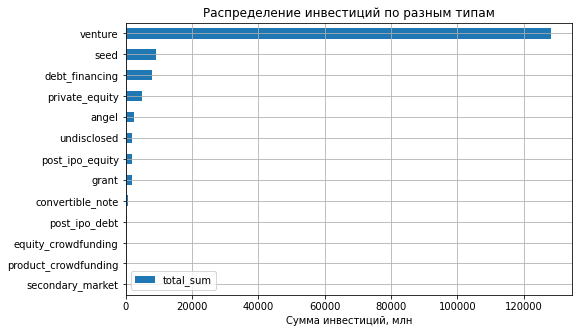

In [49]:
fin_dict_df.sort_values(by='total_sum').plot(kind = 'barh',figsize=(8,5),grid=True)
plt.title('Распределение инвестиций по разным типам')
plt.xlabel('Сумма инвестиций, млн')
plt.show()

In [50]:
count_dict_df = df_invest[finance][df_invest[finance]!=0].count().to_frame('total_count')
count_dict_df.sort_values(by='total_count')

,total_count
secondary_market,19
post_ipo_debt,75
product_crowdfunding,213
post_ipo_equity,316
equity_crowdfunding,522
convertible_note,557
undisclosed,952
grant,1142
private_equity,1373
angel,3129


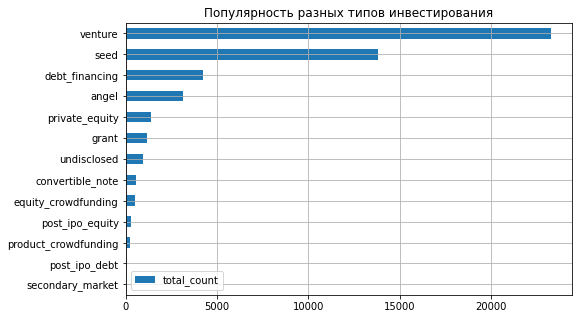

In [51]:
count_dict_df.sort_values(by='total_count').plot(kind='barh',figsize=(8,5),grid=True)
plt.title('Популярность разных типов инвестирования')
plt.xlabel('')

plt.show()

Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

In [52]:
# построим график суммарных объемов возвратов от разных типов инвестирования
return_sum = df_return[finance].sum().to_frame('total_return')
return_sum.sort_values(by='total_return',ascending=False)

,total_return
venture,40578.62
debt_financing,4734.85
private_equity,3587.33
seed,2382.24
angel,1509.23
post_ipo_equity,1104.96
undisclosed,730.88
post_ipo_debt,91.03
convertible_note,34.79
secondary_market,5.20


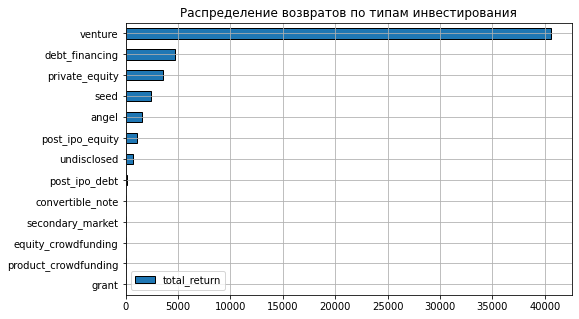

In [53]:
return_sum.sort_values(by='total_return').plot(kind='barh',grid=True,figsize=(8,5),edgecolor='black')
plt.title('Распределение возвратов по типам инвестирования')
plt.show()

**Промежуточные выводы:**

На основе анализы типов финансирования можем составить следующий рейтинг:
- по объему инвестирования: `venture` (128147.89), `seed` (911.059), `debt_financing` (8010.95)
- по частоте применения: `venture` (23277), `seed` (13840), `debt_financing` (4225)
- по размеру возвратов: `venture` (40578.62), `debt_financing` (4734.85) , `private_equity` (3587.33), `seed` (2382.24)

Хочется отметить, что все типы инвестирования, которые приносят наибольшее количество средств, являются также самыми часто используемыми, основными лидерами в данных условиях являются  `veture`,`seed`,`debt_financing`.

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам


In [54]:
# рассчитаем средний oбъем одного раунда финансирования 
df_right['funding_avg_round'] = df_right['funding_total_usd'][df_right['funding_rounds']>0] / df_right['funding_rounds'][df_right['funding_rounds']>0]
df_right

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_C,round_D,round_E,round_F,round_G,round_H,group_invest,section,anomaly,funding_avg_round
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,mid,9.000000,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,единичное,средние,False,9.000000
3,University of Michigan,http://www.umich.edu/,|Education|,education,7.700000,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,год и менее,массовые,False,2.566667
4,Case Western Reserve University,http://www.case.edu,|Education|,education,0.540000,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,единичное,массовые,False,0.540000
7,Duke University,http://www.duke.edu,|Education|,education,8.700000,operating,USA,NC,Raleigh,Durham,...,0.0,0.0,0.0,0.0,0.0,0.0,единичное,массовые,False,8.700000
9,WeGame,http://www.WeGame.com,|Social Media|,social media,3.500000,acquired,USA,CA,SF Bay Area,San Francisco,...,0.0,0.0,0.0,0.0,0.0,0.0,год и менее,массовые,False,1.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40895,IzumoBase,http://izumobase.com/en/,|Software|,software,1.350000,operating,JPN,NaN,Tokyo,Tokyo,...,0.0,0.0,0.0,0.0,0.0,0.0,единичное,массовые,False,1.350000
40896,LoudCell Technologies,http://loudcell.com/,|Software|,software,1.000000,operating,USA,CA,SF Bay Area,Santa Clara,...,0.0,0.0,0.0,0.0,0.0,0.0,единичное,массовые,False,1.000000
40897,A Crowd of Monsters,http://acrowdofmonsters.com,|Games|,games,0.560248,operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,единичное,массовые,False,0.560248
40903,SouthGobi Resources,http://southgobi.com,|Mining Technologies|,niche,9.000000,operating,CAN,BC,Vancouver,Vancouver,...,0.0,0.0,0.0,0.0,0.0,0.0,единичное,нишевые,False,9.000000


In [55]:
# сгруппируем данные по годам и найдем типичный объес инвестиций, количество раундов инвестирования
df_right['year'] = df_right['mid_funding_at'].dt.year
df_dinamic = df_right.groupby('year').agg({'funding_total_usd':'mean','funding_rounds':'count'})
df_dinamic = df_dinamic.reset_index()
df_dinamic

,year,funding_total_usd,funding_rounds
0,2000,7.087374,50
1,2001,6.732880,32
2,2002,5.713534,32
3,2003,6.401433,49
4,2004,8.920418,90
5,2005,7.393391,662
6,2006,8.121855,1052
7,2007,7.280542,1320
8,2008,7.172385,1694
9,2009,5.909496,2359


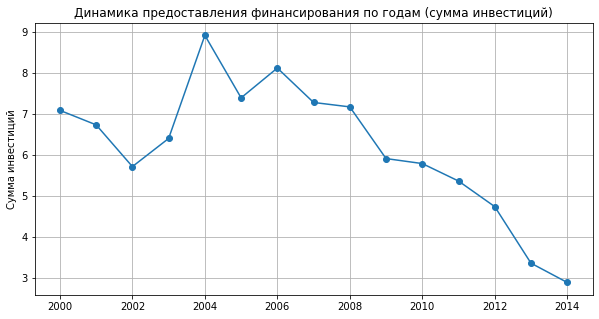

In [56]:
plt.figure(figsize=(10,5))
plt.plot(df_dinamic['year'],df_dinamic['funding_total_usd'],marker='o')
plt.grid(True)
plt.title('Динамика предоставления финансирования по годам (сумма инвестиций)')
plt.ylabel('Сумма инвестиций')
plt.show()

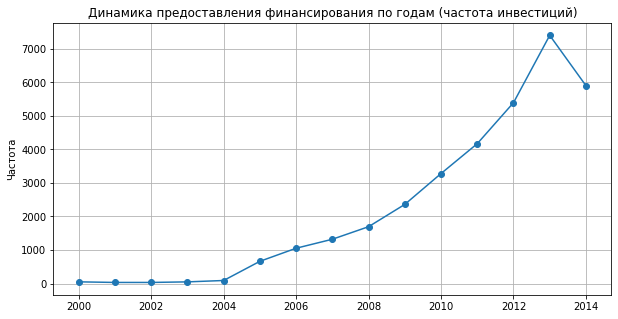

In [57]:
plt.figure(figsize=(10,5))
plt.plot(df_dinamic['year'],df_dinamic['funding_rounds'],marker='o')
plt.grid(True)
plt.title('Динамика предоставления финансирования по годам (частота инвестиций)')
plt.ylabel('Частота')
plt.show()

**Промежуточный вывод:**

На основе полученных данных можем сделать следующие выводы: в 2000-2002 и 2004-2014 наблюдается отрицталеьная динамика изменения типичного размера финасирования, в 2004 году эта величина лостигла своего максимума, преодолев отметку почти в 9000 млн долларов, однако в последующем заметен снижающийся тренд.
Что касается раундов финансирования, то с 2000 по 2013 их количество стабильно увеличивалось, в 2013 достигнув своего максимума = 7400, однако в 2014 году их количество сократилось до 5899.


### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой рассчитаем суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка, а также отберем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013, для изучения оставим только массовые сегменты.
Визуализирем для наглядности.


In [58]:
pivot_invest = pd.pivot_table(df_right,index='market',columns='year',aggfunc='sum',values='funding_total_usd',fill_value=0)
fil_pivot_invest = pivot_invest[(pivot_invest[2013]<pivot_invest[2014])]
fil_pivot_invest

year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
market,,,,,,,,,,,,,,,
apps,0.000000,0.000000,0.0,0.000000,0.0000,0.000000,0.000000,1.310600,3.050000,4.200000,8.542779,10.685736,33.279080,34.929001,69.037730
design,0.000000,0.000000,0.0,0.000000,0.0000,9.300000,0.707000,10.800000,0.344302,2.150144,8.669655,19.031825,35.717934,68.837755,69.060816
entertainment,0.100000,0.000000,0.0,0.000000,0.0000,27.450000,1.800000,15.524025,20.650000,22.269585,3.847608,46.716762,26.192770,59.558143,75.208184
internet,10.000000,0.000000,1.1,0.000000,0.0000,12.275000,0.005000,0.540000,26.388343,21.925773,26.978058,38.371042,63.988285,59.449928,117.830756
manufacturing,56.659310,2.368582,0.0,4.269608,29.0000,50.660000,90.379529,153.190008,123.868732,352.719349,316.173065,564.948500,564.946728,385.782715,479.145029
marketplaces,0.000000,0.105000,0.0,0.000000,0.0000,0.000000,0.000000,0.000000,3.885720,0.550000,4.805949,11.646932,22.371445,40.256893,41.217341
medical,24.000000,0.000000,0.0,0.000000,0.0000,11.090000,20.250000,2.100000,28.812744,13.805120,12.376418,9.379931,67.389634,70.141340,176.350145
mid,63.440389,28.326825,0.0,26.591375,56.1436,124.057912,354.254473,311.197862,430.774193,580.942138,735.424693,960.620291,1493.003019,1924.330536,2077.364226
niche,14.600000,24.020000,0.0,0.000000,0.0000,0.000000,11.015000,30.296777,27.932191,10.307736,14.042208,96.269565,61.774165,246.481941,776.526756


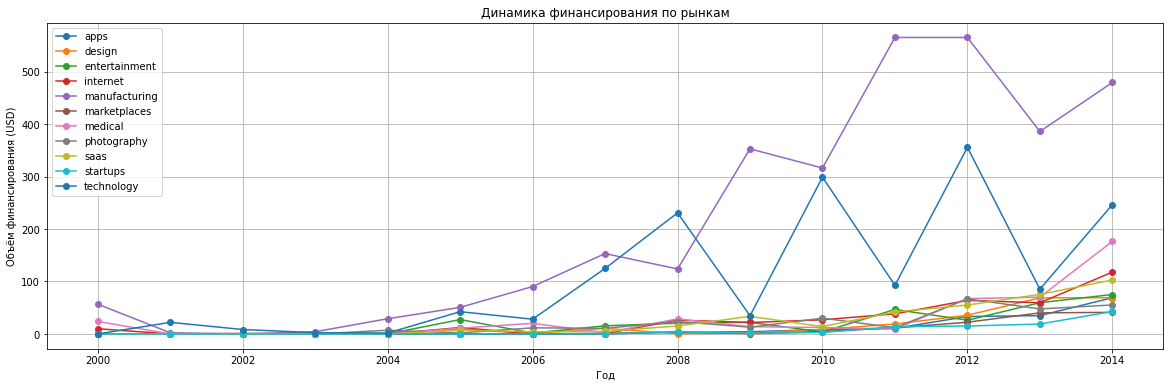

In [59]:
# Удаляем сегменты
pivot_invest_cleaned = fil_pivot_invest.drop(['mid', 'niche'])

pivot_invest_cleaned.T.plot(
    kind='line', 
    figsize=(20, 6),     
    title='Динамика финансирования по рынкам', 
    ylabel='Объём финансирования (USD)',       
    xlabel='Год',
    marker='o'
)
plt.legend(loc='upper left')
plt.grid(True)
plt.show()


**Промежуточные выводы:**

Изучив динамику финансирования сегментов на основе различных источников, стоит отметить, что для сегментов `manufacturing`,`medical`,`startups` заметен положительный тренд роста, для `apps` также заметен тренд рост, сопровождающийся значительными колебаниями.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.


In [60]:
# составим таблицу, отражающие распределение финансирования по категориям ежегодной
funding_by_year = df_right.groupby(['year'])[finance].sum()
funding_by_year

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,10.724140,203.831914,0.000000,112.202640,0.000000,4.000000,23.610000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2001,8.508268,145.014221,0.000000,55.482583,0.000000,2.000000,1.053972,0.393114,3.000000,0.000000,0.000000,0.000000,0.000000
2002,6.940192,144.692896,0.000000,22.400000,0.000000,0.000000,1.000000,0.000000,7.500000,0.300000,0.000000,0.000000,0.000000
2003,4.885416,281.085625,0.000000,16.749186,0.000000,4.350000,6.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2004,18.264728,666.215137,0.000000,58.565215,6.765834,25.500000,6.603102,8.923600,12.000000,0.000000,0.000000,0.000000,0.000000
2005,23.118724,4790.271262,0.000000,0.000000,0.000000,30.133622,40.158800,10.742481,0.000000,0.000000,0.000000,0.000000,0.000000
2006,54.410886,8310.787691,0.000000,29.454548,0.000000,81.919460,53.381836,0.750000,2.300000,3.467747,0.000000,7.718867,0.000000
2007,148.416133,8966.300674,0.000000,97.444286,5.917734,128.885728,151.478975,41.872245,70.000000,0.000000,0.000000,0.000000,0.000000
2008,233.933910,11118.940858,0.000000,59.618970,7.047669,345.470780,223.107586,17.451541,144.448891,0.000000,0.000000,0.000000,0.000000


In [61]:
#разделим таблицу возвратов на таблицу инвестирования, заменив нулевые начения на пропуски
fund_return = df_return.div(funding_by_year.replace(0, float('nan')))
fund_return

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,1.557234,0.271793,NaN,0.697042,NaN,2.165000,0.272342,NaN,NaN,NaN,NaN,NaN,NaN
2001,0.338494,0.161984,NaN,0.387509,NaN,2.245000,1.119574,0.0,0.000000,NaN,NaN,NaN,NaN
2002,0.949541,1.447341,NaN,1.150446,NaN,NaN,3.410000,NaN,0.201333,1.133333,NaN,NaN,NaN
2003,1.584307,0.831988,NaN,0.561221,NaN,0.250575,0.516667,NaN,NaN,NaN,NaN,NaN,NaN
2004,0.543671,0.834415,NaN,0.566719,0.001478,0.531373,1.390256,0.0,0.182500,NaN,NaN,NaN,NaN
2005,1.150583,0.548804,NaN,NaN,NaN,1.164480,0.773429,0.0,NaN,NaN,NaN,NaN,NaN
2006,1.135986,0.373031,NaN,1.586852,NaN,1.381967,0.894499,0.0,7.247826,5.934689,NaN,0.015546,NaN
2007,0.474409,0.399872,NaN,0.568222,0.544127,0.975127,1.086025,0.0,1.268714,NaN,NaN,NaN,NaN
2008,0.383527,0.244360,NaN,0.688036,0.242633,1.150720,0.460899,0.0,0.902603,NaN,NaN,NaN,NaN


Построим график, на котором отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

In [62]:
#исключим аномалии
fund_return['private_equity'].quantile(0.95)

4.0900356508799405

In [63]:
fund_return.loc[fund_return['angel']> 1.9961789695206869, 'angel'] = float('nan')
fund_return.loc[fund_return['private_equity']> 4.0900356508799405, 'private_equity'] = float('nan')

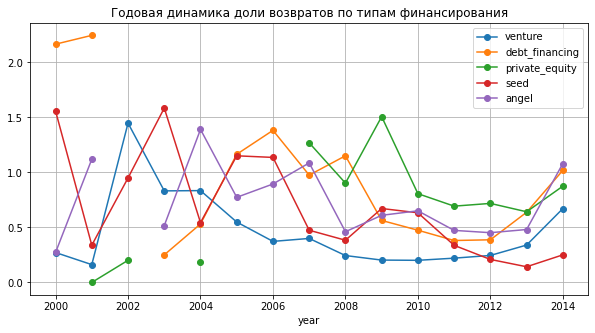

In [66]:
selected_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

# Строим линейный график
fund_return[['venture', 'debt_financing', 'private_equity', 'seed', 'angel']].plot(kind='line'
                                                                                   ,marker='o'
                                                                                   ,figsize=(10,5)
                                                                                   ,grid=True)
plt.title('Годовая динамика доли возвратов по типам финансирования')
plt.show()

**Промежуточный вывод:**

В ходе анализа годовой димаки возращенных средств по типам инвестирования было вявлено, что наиболее устойчивые типы финансирования `venture`, `seed`. Что касается `debt_financing` и `angel`, то эти типы являются менее стабильными, в 2003 и 2001 году возврат по ним не был осуществлен, возможно это связано с особенностями инвестирования, а возможно пропуски возникли в результате нестабильной ситуации компаний, данный опрос требует более детального изучения с привлечение соответсвующих данных.


## Шаг 5. Итоговый вывод и рекомендации

**Вывод**

В ходе выполнения проекта были последовательно реализованы следующие этапы: ознакомление с данными, их предобработка, инжиниринг признаков, обработка выбросов и заполнение пропусков с учётом контекста каждой переменной. Проведён комплексный анализ типов инвестирования и сегментов рынка, а также исследована годовая динамика вложений и возвратов инвестированных средств.

На первом этапе предобработки для обеспечения корректности анализа из датасета df_invest было исключено 24,7% записей. Анализ распределения компаний по группам показал, что наибольшая доля (59,4%) приходится на «единичное финансирование». При этом объёмы инвестиций в данной категории относительно невысоки, что свидетельствует о развитом рынке краткосрочных малых вложений, востребованных компаниями, нуждающимися в оперативном привлечении средств. В противоположность этому, стратегия инвестирования сроком «более года» менее популярна по числу сделок, однако позволяет привлекать значительно большие объёмы капитала — на неё приходится 61,9% всех денежных средств рынка. Такой подход характерен для крупных компаний с долгосрочными производственными проектами.

При распределении сегментов по категориям были выделены нишевые (до 10 компаний), средние (45–65) и массовые (от 120 компаний). Массовые сегменты, ввиду их значительного размера, анализировались индивидуально. Выявлено, что такие сегменты, как marketplaces, apps и startups, требуют минимальных вложений, тогда как semiconductors, clean technology и health care нуждаются в крупных долгосрочных инвестициях. При этом сегменты с меньшими вложениями и коротким сроком окупаемости демонстрируют более быстрый возврат средств. Дополнительное внимание привлекли аномальные доли возвратов в сегментах real estate (17,2%), entertainment (16,7%) и consulting (16,2%). Первые два не вызывают подозрений, тогда как показатель в consulting выглядит нетипично и требует углублённого изучения.

Анализ типов финансирования показал, что venture, debt_financing и seed являются наиболее устойчивыми инструментами: они генерируют наибольший объём привлечённых средств и обеспечивают высокий процент возврата, что делает их предпочтительными для консервативных стратегий.

Изучение годовой динамики инвестиций выявило спад в 2014 году как по количеству раундов, так и по объёмам вложений, что могло замедлить темпы роста компаний. В связи с этим в 2015 году вероятен повышенный спрос на значительные объёмы финансирования для восстановления позиций. Однако причины данного спада требуют дополнительного анализа: он может быть связан как с органическим развитием бизнеса и снижением потребности во внешнем капитале, так и с ухудшением платёжеспособности компаний и ростом долговой нагрузки.

Примечательно, что в 2014 году наблюдалось увеличение интереса к более консервативным направлениям — manufacturing и medical. Инвестиции в эти сектора с использованием надёжных инструментов (venture, seed, debt_financing) выглядят перспективными. Кроме того, зафиксирован рост заёмного капитала среди startups — направление пока не получило широкого распространения, что создаёт уникальную рыночную возможность. Тем не менее, выход в этот сегмент должен сопровождаться тщательной проверкой бизнес-модели и рыночной актуальности стартапов, чтобы минимизировать риски отсутствия потребительского спроса.